In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import RNA
from scipy.special import gammaln

In [2]:
import os
import sys
import pickle

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.environ.setdefault("RNA_STRUCT_HOME", repo_root)
sys.path.insert(0, repo_root)
os.chdir(repo_root)  # so relative paths below resolve the same way the scripts do

In [4]:
alpha = 0.01
boundaries = 1.

In [5]:
pop1 = '80'
which_run = 'synthetic_bistable_main'

path_phys_params = os.path.join(
    'fits_paper', 'designed_sequence', 'synthetic', 
#    'pop0'+pop1+'.txt')
     'reference_physical_params.txt')
#path_exp_mut_data =os.path.join(
#    'fits_paper', 'designed_sequence', 'outputs', which_run, 'synthetic_bistable_'+pop1,'detailed', 'data', 'bistable_synthetic_'+pop1+'_50mM_r0.csv')
eps_path =os.path.join(
    'fits_paper', 'designed_sequence', 'outputs', which_run, 'synthetic_bistable_'+pop1,'detailed', 'bistable_synthetic_'+pop1+'_eps_b.npy')

# which_run_merge='synthetic_bistable_notebook_patched'
#which_alpha_run='synthetic_bistable_80_init_guess_giuse'

which_run_merge='synthetic_bistable_patched_full_fit'
which_alpha_run='synthetic_bistable_80'

path_merge_sc =os.path.join(
    'fits_paper', 'designed_sequence', 'outputs', which_run_merge, which_alpha_run, 'params1D.txt')

which_run_merge = 'compare_alpha_scan_pop'+pop1
which_alpha_run = 'alpha_'+str(alpha)

path_exp_mut_data =os.path.join(
    'fits_paper', 'designed_sequence', 'outputs', which_run_merge, which_alpha_run, 'detailed', 'data', 'bistable_synthetic_'+pop1+'_50mM_r0.csv')

In [6]:
df_mutations = pd.read_csv(path_exp_mut_data)
#df_mutations = pd.read_csv('/u/m/mmaglion/Documents/MERGE-RNA_restored/fits_paper/designed_sequence/outputs/compare_alpha_scan_pop80/alpha_1/detailed/data/bistable_synthetic_80_50mM_r0.csv')

sequence = df_mutations.ref_nt.values
mutation_counts = df_mutations.mut_count.values
coverage_per_site = df_mutations.total_count.values

print(sequence),len(sequence)

['U' 'A' 'A' 'U' 'A' 'C' 'G' 'A' 'C' 'U' 'C' 'A' 'C' 'U' 'A' 'U' 'A' 'G'
 'G' 'G' 'C' 'A' 'U' 'U' 'A' 'U' 'G' 'C' 'C' 'A' 'C' 'A' 'G' 'C' 'C' 'A'
 'A' 'U' 'C' 'C' 'C' 'C' 'A' 'C' 'U' 'U' 'C' 'A' 'A' 'C' 'U' 'C' 'A' 'C'
 'A' 'A' 'C' 'U' 'A' 'U' 'U' 'C' 'C' 'A' 'A' 'A' 'A' 'A' 'A' 'U' 'U' 'G'
 'G' 'A' 'A' 'U' 'A' 'G' 'U' 'U' 'G' 'U' 'G' 'A' 'G' 'U' 'U' 'G' 'A' 'A'
 'G' 'U' 'G' 'G' 'G' 'G' 'A' 'U' 'U' 'A' 'A' 'A' 'A' 'A' 'A' 'U' 'C' 'C'
 'C' 'C' 'A' 'C' 'U' 'U' 'C' 'A' 'A' 'C' 'U' 'C' 'A' 'C' 'A' 'A' 'C' 'U'
 'A' 'U' 'U' 'C' 'C' 'A' 'A' 'C' 'C' 'U' 'C' 'C' 'A' 'G' 'C' 'A' 'G' 'A'
 'C' 'C' 'A' 'U']


(None, 148)

In [7]:
seq = "".join(sequence)
fc=RNA.fold_compound(seq)
fc.pf()
bpp=fc.bpp()
bpp = np.array(fc.bpp())[1:,1:]
bpp+=bpp.T
bpp=np.sum(bpp,axis=0)

In [8]:
phys_const_from_fit_metadata = {"temp_C": 37, "conc_mM": 50}

### Compute parameters of the "mutation probability" from merge_rna output data
No explicit expression of the parameters needs to be written

First we copied (and slightly modified) help functions for handling physical parameters from files and for paching them in the format needed. Consider that also the temp and conc need to be retrieved (non fitted physical parameters), for now I do it manually since they are only two

In [9]:
def convert_p_bind_1d_to_dict(p_bind_1d, DMS_mode=True):
    '''Convert the 1D array of p_bind to a dictionary.
    If DMS_mode is True, input is a 4-element array and will put 0A, 0C to 0 and 1G, 1U to equal to  0G, 0U.'''
    list_partial_keys = ["p_bind_A_", "p_bind_C_", "p_bind_G_", "p_bind_U_"]
    if DMS_mode:
        p_bind_dict = {incom_key+"0": value for incom_key, value in zip(list_partial_keys, p_bind_1d)}
        p_bind_dict["p_bind_A_"+"1"] = 0
        p_bind_dict["p_bind_C_"+"1"] = 0
        p_bind_dict["p_bind_G_"+"1"] = p_bind_dict["p_bind_G_"+"0"]
        p_bind_dict["p_bind_U_"+"1"] = p_bind_dict["p_bind_U_"+"0"]
    else:
        list_keys = []

        for str in ["0", "1"]:
            list_keys.append(str.join(list_partial_keys))

        p_bind_dict = {key: value for key, value in zip(list_keys, p_bind_1d)}
    return p_bind_dict

In [10]:
def pack_params(params_1d, dict_with_phys_params_pos):
    '''Unpacks the 1D array of parameters into a dictionary.'''
    params = {}
    for param, pos in dict_with_phys_params_pos.items():
        params[param] = params_1d[pos]
    # Convert the 1D array for p_bind into a dictionary.
    p_bind_dict = convert_p_bind_1d_to_dict(params['p_bind'])
    # maybe I will implement the test later
    return params

In [11]:
def _generate_phys_params_positions(DMS_mode=True):
    '''Generate parameter positions mapping'''
    base_config = {
        'mu_r': 0,
        'p_b': 1,
        'p_bind': list(range(2, 10 if not DMS_mode else 6)),
        'm0': 10 if not DMS_mode else 6,
        'm1': 11 if not DMS_mode else 7,
    }
    params_pos = base_config.copy()
    return params_pos

In [12]:
pos_dict = _generate_phys_params_positions()
print(pos_dict)

{'mu_r': 0, 'p_b': 1, 'p_bind': [2, 3, 4, 5], 'm0': 6, 'm1': 7}


In [13]:
#vec_phys_params = np.loadtxt(path_phys_params)
vec_phys_params = np.loadtxt(path_merge_sc)

phys_params_dict = pack_params(vec_phys_params,pos_dict)
print(phys_params_dict)

{'mu_r': np.float64(2.526827704255335), 'p_b': np.float64(1.2628884887648573), 'p_bind': array([0.07777946, 0.05504757, 0.03156236, 0.00716421]), 'm0': np.float64(9.848747842482197e-05), 'm1': np.float64(0.30169656327796857)}


In [14]:
# The eps are fitted physical parameters
eps_vec = np.load(eps_path, mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')
print(eps_vec)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


Now I write a function that uses the same machinery used in merge rna to compute the average probability of mutation,
$$
\langle M_i \rangle = a_i+b_i\, \langle s_i \rangle
$$
but it runs it with pairing probs equal to $0$ and $1$. \
I write the function in order to give the coefficients of the mutation rate in the form:
$ M_i = a_i+b_i\,s_i $
, but maybe it could be better to use an expression $ M_i = 1-a'_i+(a'_i-b'_i)s_i $  to neglect some cancellation that happens in $b_i$ where there is a difference between two close numbers. \
The two close numbers are 
$$
\frac{e^{\beta \, \mu}}{1+ e^{\beta \, \mu}} \qquad \frac{e^{\beta \, (\mu - \Delta \mu)}}{1+ e^{\beta \, (\mu - \Delta \mu)}}
$$
When the nucleotides are U or G, since in their case the p_bind is independent of the contact state of the nucleotide

In [15]:
def mut_prob_condit_contact_merge_rna(seq,eps_b,*,
                            conc_mM,temp_C,
                            #p_bind_A_0, p_bind_A_1, p_bind_U_0, p_bind_U_1, p_bind_C_0, p_bind_C_1,p_bind_G_0, p_bind_G_1,
                            p_bind,
                            mu_r, p_b, m0, m1):
    
    kBT = (273.15 + temp_C) * (1.98717/1000) # kcal/mol, matches fit.py's self.kBT = self.temp_K * kb
    beta = 1/kBT
    mu_j = mu_r + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu_r
    f_mu = np.exp(beta*mu_j)/(1-np.exp(beta*mu_j))
    f_mu_prime = np.exp(beta*(mu_j-p_b))/(1-np.exp(beta*(mu_j-p_b)))

    dict_pbind = convert_p_bind_1d_to_dict(p_bind) 

    def compute_penalty_m(mu, p_b_):
        '''Compute the penalty for paired bases in kcal/mol'''
        mu_prime = mu-p_b_
        penalty_in_kbt = -math.log((1+math.exp(beta*mu_prime))/(1+math.exp(beta*mu)))
        penalty_in_kcal_per_mol = penalty_in_kbt * kBT #TBC: to be checked
        return penalty_in_kcal_per_mol

    def compute_mu_dependent_quantities(mu, p_b_):
        '''Returns some key quantities that depend on mu: e^beta*mu, e^beta*mu', p(c_b|s_b,n_b)'''
        mu_prime = mu - p_b_
        e_beta_mu = math.exp(beta*mu)
        e_beta_mu_prime = math.exp(beta*mu_prime)
        e_beta_mu_norm = e_beta_mu / (1 + e_beta_mu)
        e_beta_mu_prime_norm = e_beta_mu_prime / (1 + e_beta_mu_prime)
        # probability of chemical binding
        p_cb_given_sb_nb = dict() # p(cb=1|s_b,n_b) -> p_cb[(s_b,n_b)] , cb = 1 is implicit.
        for s_b in [0, 1]:
            physical_binding_probability = e_beta_mu_norm if s_b == 0 else e_beta_mu_prime_norm
            for n_b in ['A', 'C', 'G', 'U']:
                p_cb_given_sb_nb[(s_b, n_b)] = dict_pbind["p_bind_"+n_b+"_"+str(s_b)] * physical_binding_probability # p(cb=0|s_b,n_b) = 1 - p(cb=1|s_b,n_b)
        return e_beta_mu, e_beta_mu_prime, p_cb_given_sb_nb

    def compute_p_cb(mu, p_b_, pairing_probs):
        '''Compute p(c_b) for the whole sequence'''
        # compute mu dependent quantities (and p(c_b|s_b,n_b))
        _, _, p_cb_given_sb_nb = compute_mu_dependent_quantities(mu, p_b_)
        # apply penalty for paired bases
        penalty = compute_penalty_m(mu, p_b_)
        # compute p(s_b)
        try:
            assert 0 <= penalty <= 5
        except AssertionError:
            print('Warning, penalty is not in [0,5]')
            print(f'penalty: {penalty}, mu: {mu}, p_b: {p_b}')
        # compute p(c_b)
        p_cb = np.zeros(len(seq))
        for i,nb in enumerate(seq):    # weighted sum over s_b=0,1
            p_cb[i] = p_cb_given_sb_nb[(1, nb)]*pairing_probs[i] + p_cb_given_sb_nb[(0, nb)]*(1-pairing_probs[i])
        return p_cb

    # 2a: mutation profile model
    def compute_mutation_profile(m0, m1,eps_b, p_cb):
        '''Compute the mutation profile predicted by the model with the current parameters.
        Later: compute its derivatives'''
        # compute mutation profile
        Mb = 1 - np.exp(-eps_b) * (math.exp(-m0) +  p_cb*(math.exp(-m1) - math.exp(-m0)))
        return Mb
    
    a_merge = compute_mutation_profile(m0, m1, eps_b, compute_p_cb(mu_j, p_b, np.zeros(len(seq))))
    a_plus_b_merge = compute_mutation_profile(m0, m1, eps_b, compute_p_cb(mu_j, p_b, np.ones(len(seq))))
    return a_merge, a_plus_b_merge-a_merge

In [16]:
a_from_merge, b_from_merge = mut_prob_condit_contact_merge_rna(sequence, eps_vec, **phys_const_from_fit_metadata, **phys_params_dict)

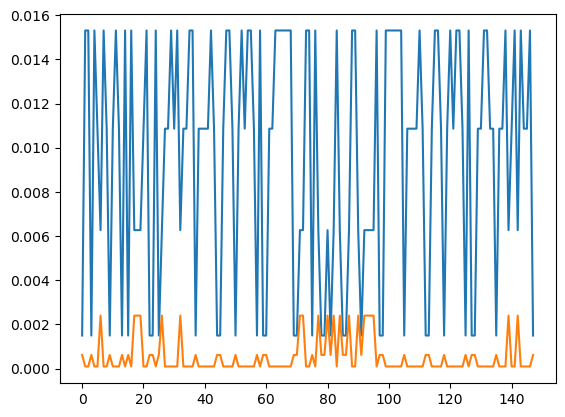

In [17]:
plt.plot(a_from_merge)
plt.plot(a_from_merge+b_from_merge)

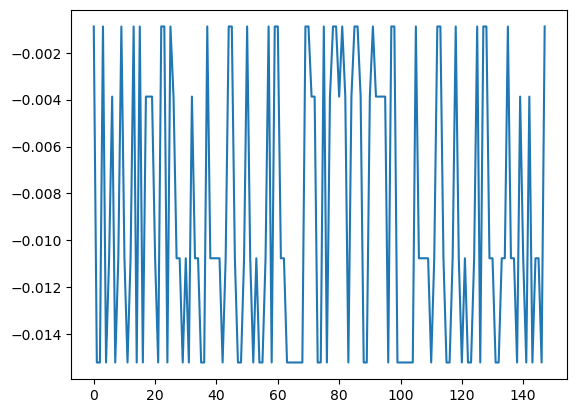

In [18]:
plt.plot(b_from_merge)

Then I take the expressions from Giovanni's notes on the approximation of the likelihood function
$$
    S^{\text{exp}}_i = \frac{z_i-T_i\, a_i}{T_i \, b_i} \qquad \frac{1}{\sigma_i^2}= \frac{b_i^2\, T_i^3}{(T_i-z_i)z_i}
$$
where $z_i$ is the mutation count, $T_i$ is the coverage at site i. \
In particular $S^{\text{exp}}_i$ would be the value of the pairing probability that would give the experimental mutation counts observed, for given $a_i$ e $b_i$.

In [19]:
# modified with proper z=0 case
def compute_expansion_parameters(z, T, a, b):
    target_contact_prob = (z-T*a)/(T*b)
    squared_confidence_interval = np.zeros(len(z))
    for i in range(len(z)):
        if z[i] != 0:
            squared_confidence_interval[i] = ((T[i] - z[i]) / T[i]) * (z[i] / T[i]**2) / b[i]**2
        else: 
            squared_confidence_interval[i] = 1/(T[i]*b[i]**2)
    return target_contact_prob, squared_confidence_interval

In [20]:
target_contact_prob, squared_confidence_interval = compute_expansion_parameters(mutation_counts, coverage_per_site, a_from_merge, b_from_merge)

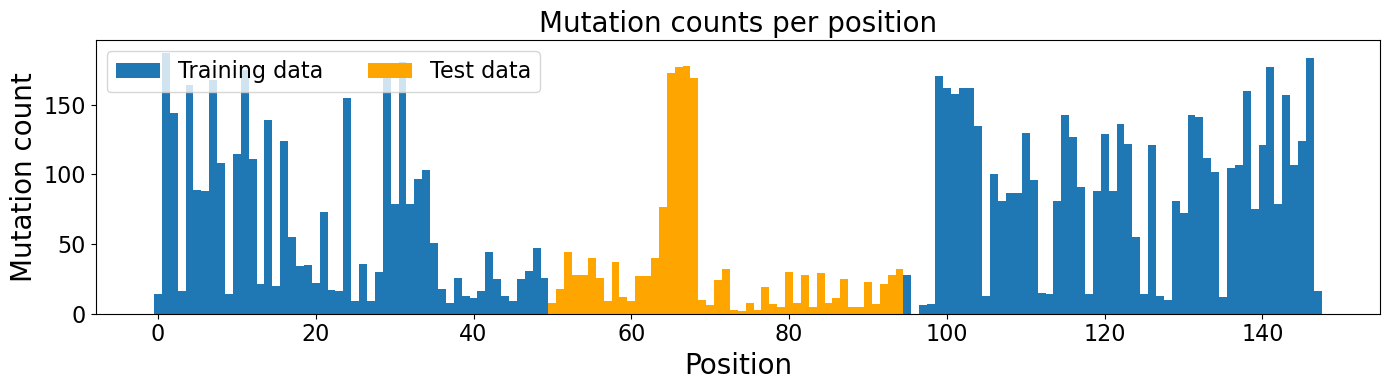

In [47]:
test_positions_interv = (50,95)
test_positions = np.arange(test_positions_interv[0], test_positions_interv[1])

plt.figure(figsize=(14, 4))
plt.bar(df_mutations.index, df_mutations.mut_count, width=1.0, label='Training data')
plt.bar(df_mutations.index[test_positions], df_mutations.mut_count[test_positions], width=1.0, color='Orange', label='Test data')
plt.xlabel('Position',fontsize=20)
plt.ylabel('Mutation count',fontsize=20)
plt.tick_params(axis='both', labelsize=16)
plt.legend(fontsize=16, ncol=2)
title = 'Mutation counts per position'

plt.title(title, fontsize=20)
plt.tight_layout()
plt.show()

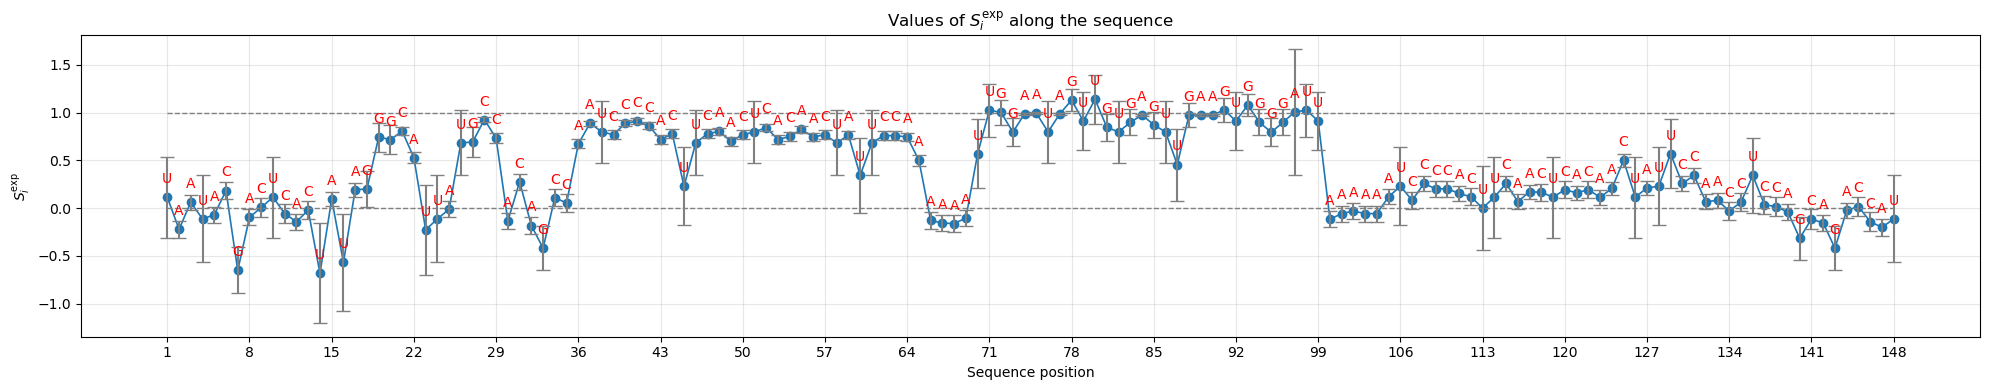

In [21]:
# positions along the sequence
positions = np.arange(1, len(sequence) + 1)

# b_from_fit is the array you already computed
y = target_contact_prob
y_errors = np.sqrt(squared_confidence_interval)

fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(positions, y, marker='o', linestyle='-', linewidth=1.2, color='tab:blue')
ax.errorbar(positions, y, yerr=y_errors, ecolor='gray', fmt='none', capsize=5)

# add nucleotide letters near each point
for x, yy, nt in zip(positions, y, sequence):
    ax.annotate(
        nt,
        xy=(x, yy),
        xytext=(0, 8),           # offset upward
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="red"
    )

ax.set_xticks(positions[::7])

ax.hlines(y=0, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)
ax.hlines(y=1, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)

ax.set_xlabel("Sequence position")
ax.set_ylabel(r"$S^{\text{exp}}_i$")
ax.set_title(r"Values of $S^{\text{exp}}_i$ along the sequence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Some $S_i^{\text{exp}}$ sono non fisici, principalmente quelli per i nucleotidi U, G che sono poco informativi (questo è legato a quello che si diceva prima del piccolo valore di b_i) (questo è vero per i dati puramente sintetici, da verificare con dati sperimentali reali). \
This could maybe be improved by using data that actually sampled from  a binomial. \
I think that a big role is played by the fact that the eps are 0 and by the fact that the physical parameters are fitted globally.

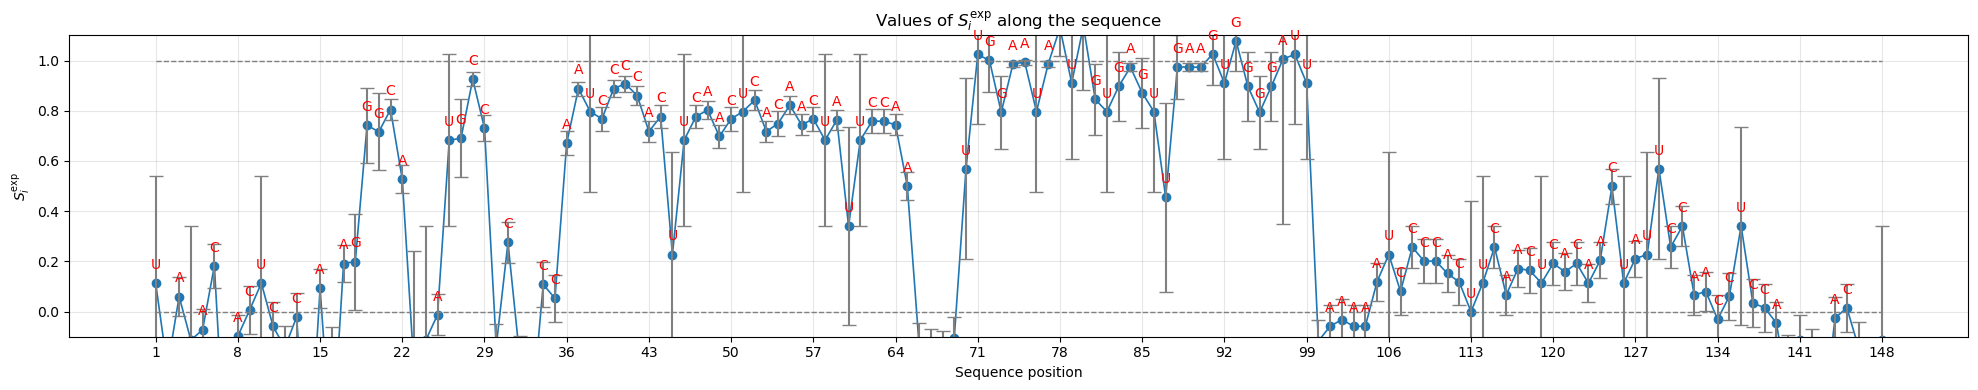

In [22]:
ax.set_ylim(-0.1, 1.1)  # Set y-axis limits to show the S_i in the physical range
#plt.draw() seems to not work
fig.canvas.draw_idle()
fig     

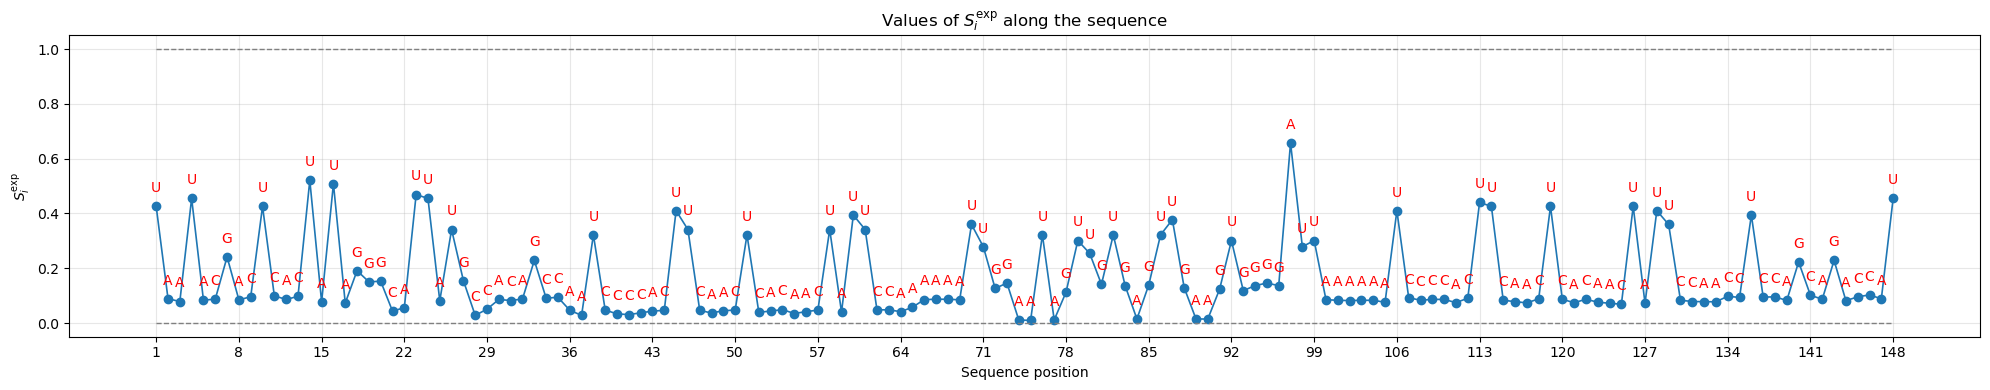

In [23]:
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(positions, y_errors, marker='o', linestyle='-', linewidth=1.2, color='tab:blue')

# add nucleotide letters near each point
for x, yy, nt in zip(positions, y_errors, sequence):
    ax.annotate(
        nt,
        xy=(x, yy),
        xytext=(0, 8),           # offset upward
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="red"
    )

ax.set_xticks(positions[::7])

ax.hlines(y=0, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)
ax.hlines(y=1, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)

ax.set_xlabel("Sequence position")
ax.set_ylabel(r"$S^{\text{exp}}_i$")
ax.set_title(r"Values of $S^{\text{exp}}_i$ along the sequence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
y_errors[y_errors==0]

array([], dtype=float64)

### Define and run the optimizers

In [25]:
def compute_penalty_m(temp_C, conc_mM, mu, p_b):
    '''Compute the penalty for paired bases in kcal/mol'''
    kBT = (273.15 + temp_C) * (1.98717/1000) # kcal/mol, matches fit.py's self.kBT = self.temp_K * kb
    beta = 1/kBT
    mu_j = mu + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu
    mu_prime = mu_j-p_b
    penalty_in_kbt = -math.log((1+math.exp(beta*mu_prime))/(1+math.exp(beta*mu_j)))
    penalty_in_kcal_per_mol = penalty_in_kbt * kBT #TBC: to be checked
    return penalty_in_kcal_per_mol

In [26]:
def maxent(seq,bpp_ref,*, sigma_squared, penalty=None, boundaries=None, natural_boundaries=True,
           initial_guess=None, rescale=True,version=0,T=None,deriv_correct=False,alpha=0.0,tol=None):
    # seq: sequence
    # bpp_ref: array with base pairing probabilities to be enforced
    # sigma_squared error estimate, enters in derivative and regularization
    
    # boundaries: applUUUy boundaries on lambda.
    #   a number (e.g., 2), means all lambdas are in (-2,+2)
    #   alternatively, pass a (N,2) array with minumum (:,0) and maximum (:,1)
    
    # alpha: KL regularization
    from scipy.optimize import minimize

    kb=1.98717/1000 # grepped from vienna source code
    kBT = ((RNA.cvar.temperature + 273.15) * kb)
    beta = 1.0/kBT

    if T is not None:
        save_T=RNA.cvar.temperature
        RNA.cvar.temperature=T
    
    fc=RNA.fold_compound(seq)
    if rescale:
        fc.mfe()
        fc.exp_params_rescale(0.01*fc.mfe()[1])
    
    # if isinstance(boundaries,float):
    #     boundaries=boundaries*np.ones((len(seq),2))
    #     boundaries[:,0]*=-1

    if natural_boundaries:
        # natural boundaries are the ones that guarantee that the pairing probability is in [0,1]
        # for a given a_phys, b_phys, and mutation counts
        natural_min_lambda=-bpp_ref/(alpha*sigma_squared)
        natural_max_lambda=(1-bpp_ref)/(alpha*sigma_squared)
        boundaries = np.array([(natural_min_lambda[i], natural_max_lambda[i]) for i in range(len(natural_min_lambda))])
        boundaries = boundaries/(beta*alpha)  # make adimensional for the optimizer
    else:
        if isinstance(boundaries,float) or isinstance(boundaries,int):
            boundaries=boundaries*np.ones((len(seq),2))
            boundaries[:,0]*=-1
    
    def Gamma(lambdas):
        
        if deriv_correct:
            lambdas_rounded=np.round(lambdas,2)
            dlambdas=lambdas-lambdas_rounded
            lambdas=lambdas_rounded
        else:
            dlambdas=lambdas*0.0
        
        if penalty is not None:
            for i in range(len(seq)):
                for j in range(i+1,len(seq)):
                    fc.sc_add_bp(i+1,j+1,2*penalty) # penalty is already in kcal/mol
        
        shift=0.0
        for i in range(len(lambdas)):
            m=lambdas[i]
            if m==0:
                continue
            elif version==1 or (version==0 and m<0):
                fc.sc_add_up(i+1,-m) # vienna takes positions starting from 1
                shift+=m
            elif version==2 or (version==0 and m>0):
                for j in range(len(lambdas)):
                    if j>i:
                        fc.sc_add_bp(i+1,j+1,m)
                    if j<i:
                        fc.sc_add_bp(j+1,i+1,m)
        F=fc.pf()[1]+shift
        gamma=-F+np.dot(lambdas,bpp_ref)
        bpp = np.array(fc.bpp())[1:,1:]
        bpp+=bpp.T
        bpp=np.sum(bpp,axis=0)
        gradients=bpp_ref-bpp
        # correction on gamma - but it does not correct the gradients...
        # this means the minimization might fail
        
        gamma+=np.dot(gradients,dlambdas)
        
        # L2 regularization
        gamma+= 0.5*alpha*beta*np.sum(sigma_squared*(lambdas+dlambdas)**2)
        gradients += alpha*beta*sigma_squared*(lambdas+dlambdas)
        
        fc.sc_init()
        
        return gamma,gradients
    
    if initial_guess is None:
        initial_guess=np.zeros(len(seq))
    else:
        initial_guess=np.array(initial_guess)
    
    if tol is None:
        res=minimize(Gamma,initial_guess,jac=True,method="L-BFGS-B",bounds=boundaries)
    else:
        res=minimize(Gamma,initial_guess,jac=True,method="L-BFGS-B",bounds=boundaries,tol=tol)
        
        
    if T is not None:
        RNA.cvar.temperature=save_T
        
    return res,bpp_ref-res.jac+alpha*beta*sigma_squared*res.x

In [27]:
def maxent_binomial(seq, mutation_counts, trials_counts, a_phys, b_phys,*, penalty=None, boundaries=None, initial_guess=None, rescale=True,version=0,T=None,deriv_correction=False,alpha=0.0,tol=None):
    # seq: sequence
    # mutation_counts: array with number of mutations counted per site
    # trials_counts: array with number of attempted mutations per site

    # a_phys, b_phys: arrays of physical parameters for the mutation probability

    # boundaries: apply boundaries on lambda.
    #   a number (e.g., 2), means all lambdas are in (-2,+2)
    #   alternatively, pass a (N,2) array with minumum (:,0) and maximum (:,1)
    
    # alpha: KL regularization
    from scipy.optimize import minimize

    if T is not None:
        save_T=RNA.cvar.temperature
        RNA.cvar.temperature=T

    kb=1.98717/1000 # grepped from vienna source code
    kBT = ((RNA.cvar.temperature + 273.15) * kb)
    beta = 1.0/kBT
    #beta = 1
    
    fc=RNA.fold_compound(seq)
    if rescale:
        fc.mfe()
        fc.exp_params_rescale(0.01*fc.mfe()[1])


    if isinstance(boundaries,float):
        boundaries=boundaries*np.ones((len(seq),2))
        boundaries[:,0]*=-1
    elif boundaries is None:
        boundaries = np.array([(None, None)]*len(seq))

    frac_phys = a_phys/b_phys
    inv_b_phys = 1.0/b_phys

    def inverse_loss_derivative(lams):
        # lams must be adimensional
        # when lams is 0 (or alpha is 0), the results should be -frac_phys + inv_b_phys*mutation_counts/trials_counts
        lams_prime = lams*alpha/b_phys
        S = np.sqrt((trials_counts - lams_prime)**2 + 4*mutation_counts*lams_prime)
        result =  -frac_phys + inv_b_phys*2*mutation_counts / (S - (lams_prime - trials_counts))
        #print(result-(-frac_phys+inv_b_phys*mutation_counts/trials_counts))
        return result

    def loss_binomial(bpp_1):
        mut_prob = a_phys+b_phys*bpp_1
        return -mutation_counts*np.log(mut_prob)-(trials_counts-mutation_counts)*np.log(1-mut_prob)
    
    def deriv_loss_binomial(bpp_1):
        mut_prob = a_phys+b_phys*bpp_1
        return -b_phys*mutation_counts/mut_prob+b_phys*(trials_counts-mutation_counts)/(1-mut_prob)

    def Gamma(lambdas):
        
        if deriv_correction:
            lambdas_rounded=np.round(lambdas,2)
            dlambdas=lambdas-lambdas_rounded
            lambdas=lambdas_rounded
        else:
            dlambdas=lambdas*0.0
        
        if penalty is not None:
            for i in range(len(seq)):
                for j in range(i+1,len(seq)):
                    fc.sc_add_bp(i+1,j+1,2*penalty) # penalty is already in kcal/mol
        
        shift=0.0
        for i in range(len(lambdas)):
            m=lambdas[i]
            if m==0:
                continue
            elif version==1 or (version==0 and m<0):
                fc.sc_add_up(i+1,-m) # vienna takes positions starting from 1
                shift+=m
            elif version==2 or (version==0 and m>0):
                for j in range(len(lambdas)):
                    if j>i:
                        fc.sc_add_bp(i+1,j+1,m)
                    if j<i:
                        fc.sc_add_bp(j+1,i+1,m)
        F=fc.pf()[1] + shift

        bpp_lambda = inverse_loss_derivative(beta*lambdas) # need to make lambdas adimensional
        gamma=beta*(-F+np.dot(lambdas,bpp_lambda))
        
        bpp = np.array(fc.bpp())[1:,1:]
        bpp+=bpp.T
        bpp=np.sum(bpp,axis=0)
        gradients = beta*(-bpp + bpp_lambda)
        # correction on gamma - but it does not correct the gradients...
        # this means the minimization might fail
        
        gamma+=beta*np.dot(gradients,dlambdas)
        
        # alpha regularization

        if alpha > 0:
            gamma+= -(1.0/alpha)*np.sum(loss_binomial(bpp_lambda))
        # otherwise this becomes a constant diverging term = -1/alpha * min(binmial_loss)
        
        # alpha enters in the gradients by default so no need to add a term for alpha!=0
        # but if it is equal to zero the gradients are just chasing the pairing prob that gives the exp mutation for given a_phys, b_phys
        
        fc.sc_init()
        
        return gamma,gradients
    
    if initial_guess is None:
        initial_guess=np.zeros(len(seq))
    else:
        initial_guess=np.array(initial_guess)
    
    if tol is None:
        res=minimize(Gamma,initial_guess,jac=True,method="L-BFGS-B",bounds=boundaries)
    else:
        res=minimize(Gamma,initial_guess,jac=True,method="L-BFGS-B",bounds=boundaries,tol=tol)
        
        
    if T is not None:
        RNA.cvar.temperature=save_T
    
    # return the result of the optimization and the average pairing probs corrected by a non zero gradient
    return res,inverse_loss_derivative(beta*res.x)-res.jac

In [28]:
bpp_target=target_contact_prob
penalties = compute_penalty_m(**phys_const_from_fit_metadata, mu=phys_params_dict['mu_r'], p_b=phys_params_dict['p_b'])
tol = None

res=maxent(seq, bpp_target, sigma_squared=squared_confidence_interval, penalty= penalties, boundaries=boundaries,alpha=alpha,deriv_correct=False, tol=tol,T=phys_const_from_fit_metadata['temp_C'])
res

(  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 20094732.141139578
         x: [-1.214e+00  1.731e+05 ...  1.603e+05  3.397e+03]
       nit: 30
       jac: [-7.911e-01  2.205e+01 ...  2.009e+01  1.129e+01]
      nfev: 48
      njev: 48
  hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>,
 array([9.01163075e-01, 0.00000000e+00, 8.14145980e-02, 0.00000000e+00,
        0.00000000e+00, 4.54080317e-01, 0.00000000e+00, 0.00000000e+00,
        5.80111202e-08, 1.81993028e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.12524142e-06, 0.00000000e+00,
        5.77877627e-05, 3.52339015e-03, 2.97923967e-01, 2.48997494e-01,
        2.72801613e-02, 9.69485396e-03, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 9.24837215e-01, 4.80544570e-02, 3.63696665e-01,
        3.62918489e-01, 0.00000000e+00, 2.00646793e-02, 0.00000000e+00,
        0.00000000e+00, 3.13424097e-03, 2.28075361e-10, 6.39100990

In [29]:
penalties = compute_penalty_m(**phys_const_from_fit_metadata, mu=phys_params_dict['mu_r'], p_b=phys_params_dict['p_b'])
tol = None

res_binom=maxent_binomial(seq, mutation_counts=mutation_counts, trials_counts=coverage_per_site, a_phys=a_from_merge, b_phys=b_from_merge, penalty= penalties, boundaries=boundaries,alpha=alpha,deriv_correction=False, tol=tol,T=phys_const_from_fit_metadata['temp_C'])
res_binom

(  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: -5449199.114055652
         x: [-1.000e+00  1.000e+00 ...  1.000e+00  1.000e+00]
       nit: 21
       jac: [ 1.786e-01 -3.612e-01 ... -3.291e-01 -1.796e-01]
      nfev: 27
      njev: 27
  hess_inv: <148x148 LbfgsInvHessProduct with dtype=float64>,
 array([-0.06792748,  0.13867904, -0.03464091,  0.06904661,  0.04451296,
        -0.10723023,  0.40983237,  0.0612714 ,  0.0086063 , -0.05141952,
         0.03702313,  0.08949177,  0.01380686,  0.42267803, -0.05392504,
         0.35413573, -0.09352086,  0.16667589,  0.8198163 ,  0.77784426,
         0.71550399,  0.5591043 ,  0.14111212,  0.06937085,  0.00806206,
         0.46335004,  0.74315868,  0.67627932,  0.75417014,  0.0854432 ,
        -0.02314152,  0.11445455,  0.32010318,  0.00155032,  0.02760883,
         0.61846285,  0.71862291,  0.78867028,  0.79958153,  0.7400276 ,
         0.72955497,  0.75804501,  0.72829032,  0.79557621

### Analyze the results of the optimizers by visula inspections

In [118]:
def compute_ps_with_penalty_and_lambda(seq, lambdas, penalty, *, version=0, T=None, rescale=True):
    
    if T is not None:
        save_T=RNA.cvar.temperature
        RNA.cvar.temperature=T
    
    fc=RNA.fold_compound(seq)
    if rescale:
        fc.mfe()
        fc.exp_params_rescale(1.*fc.mfe()[1])
    if penalty is not None:
        for i in range(len(seq)):
            for j in range(i+1,len(seq)):
                fc.sc_add_bp(i+1,j+1,2*penalty) # penalty is already in kcal/mol
    
    shift=0.0
    for i in range(len(lambdas)):
        m=lambdas[i]
        if m==0:
            continue
        elif version==1 or (version==0 and m<0):
            fc.sc_add_up(i+1,-m) # vienna takes positions starting from 1
            shift+=m
        elif version==2 or (version==0 and m>0):
            for j in range(len(lambdas)):
                if j>i:
                    fc.sc_add_bp(i+1,j+1,m)
                if j<i:
                    fc.sc_add_bp(j+1,i+1,m)
    
    fc.pf()

    bpp = np.array(fc.bpp())[1:,1:]
    bpp+=bpp.T
    bpp=np.sum(bpp,axis=0)

    return bpp

In [119]:
def compute_free_energy_with_penalty_and_lambda(seq, lambdas, penalty, *, version=0, T=None, rescale=False):
    
    if T is not None:
        save_T=RNA.cvar.temperature
        RNA.cvar.temperature=T
    
    fc=RNA.fold_compound(seq)
    if rescale:
        fc.mfe()
        fc.exp_params_rescale(1.*fc.mfe()[1])
    if penalty is not None:
        for i in range(len(seq)):
            for j in range(i+1,len(seq)):
                fc.sc_add_bp(i+1,j+1,2*penalty) # penalty is already in kcal/mol
    
    shift=0.0
    for i in range(len(lambdas)):
        m=lambdas[i]
        if m==0:
            continue
        elif version==1 or (version==0 and m<0):
            fc.sc_add_up(i+1,-m) # vienna takes positions starting from 1
            shift+=m
        elif version==2 or (version==0 and m>0):
            for j in range(len(lambdas)):
                if j>i:
                    fc.sc_add_bp(i+1,j+1,m)
                if j<i:
                    fc.sc_add_bp(j+1,i+1,m)
    free_en = fc.pf()[1]+shift

    return free_en

In [120]:
vec_params_merge = np.loadtxt(path_merge_sc)
lambdas_merge_rna = vec_params_merge[8:] 

#lambdas_merge_rna = vec_phys_params[8:] ## can be used in case you took phys param from the same file as sc, which should be usually done
bpp_mergerna = compute_ps_with_penalty_and_lambda(seq, lambdas_merge_rna, penalties, version=0, T=None, rescale=True)

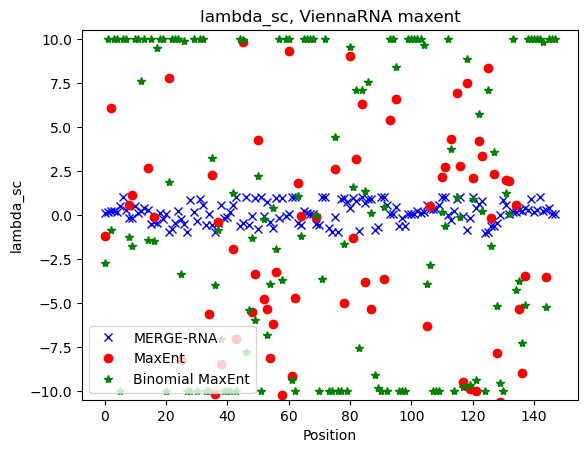

In [155]:
plt.figure()
plt.plot(range(len(lambdas_merge_rna)), lambdas_merge_rna, marker='x', linestyle='None', color='blue', label='MERGE-RNA')
plt.plot(res[0].x, marker='o', linestyle='None', color='red', label='MaxEnt')
plt.plot(res_binom[0].x, marker='*', linestyle='None', color='green', label='Binomial MaxEnt')
plt.title(f'lambda_sc, ViennaRNA maxent')
plt.xlabel('Position')
plt.ylabel('lambda_sc')
plt.ylim(boundaries*(-1-.05),boundaries*(1+.05))
plt.legend()

In [159]:
max(res[0].x),min(res[0].x)

(np.float64(173108.57443237843), np.float64(-63082.89522117098))

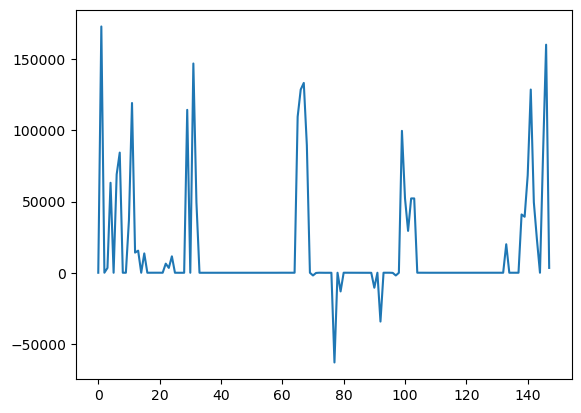

In [163]:
plt.plot(res[0].x)

In [123]:
penalties

0.6551530014902323

In [156]:
seq

'UAAUACGACUCACUAUAGGGCAUUAUGCCACAGCCAAUCCCCACUUCAACUCACAACUAUUCCAAAAAAUUGGAAUAGUUGUGAGUUGAAGUGGGGAUUAAAAAAUCCCCACUUCAACUCACAACUAUUCCAACCUCCAGCAGACCAU'

In [160]:
compute_free_energy_with_penalty_and_lambda(seq, res[0].x, penalties)

np.float64(inf)

In [125]:
import bussilab.rna2d as bussi

In [161]:
mol = bussi.Molecule(seq, lambdas1d=res[0].x+penalties*np.ones(len(seq)))

In [162]:
mol.total_free_energy()

nan

In [128]:
fc_prova=RNA.fold_compound(seq)
fc_prova.pf()

['.................{(({(...,||}...,,.|||,|||,,,,,,,,,,,,,,,,,,,,,,.....||||||||||||||||||||||||||||||....}}}}}}}}}}}}}}}}}}}}}))))}}}},...............',
 -58.77705764770508]

In [129]:
version = 0
lambdas_prova = res[0].x

shift=0.0
for i in range(len(lambdas_prova)):
    m=lambdas_prova[i]
    if m==0:
        continue
    elif version==1 or (version==0 and m<0):
        fc_prova.sc_add_up(i+1,-m) # vienna takes positions starting from 1
        shift+=m
    elif version==2 or (version==0 and m>0):
        for j in range(len(lambdas_prova)):
            if j>i:
                fc_prova.sc_add_bp(i+1,j+1,m)
            if j<i:
                fc_prova.sc_add_bp(j+1,i+1,m)
free_en = fc_prova.pf()[1]+shift
free_en

np.float64(-58.777057647705576)

In [158]:
lam = -1000
#lambdas = lam*np.ones(len(seq))
lambdas = np.zeros(len(seq))
lambdas[50] = lam

mol = bussi.Molecule(seq, lambdas1d = lambdas)

mol.total_free_energy()

nan

In [148]:
version = 0
lambdas_prova = lambdas

fc_prova=RNA.fold_compound(seq)

shift=0.0
for i in range(len(lambdas_prova)):
    m=lambdas_prova[i]
    if m==0:
        continue
    elif version==1 or (version==0 and m<0):
        fc_prova.sc_add_up(i+1,-m) # vienna takes positions starting from 1
        shift+=m
    elif version==2 or (version==0 and m>0):
        for j in range(len(lambdas_prova)):
            if j>i:
                fc_prova.sc_add_bp(i+1,j+1,m)
            if j<i:
                fc_prova.sc_add_bp(j+1,i+1,m)
free_en = fc_prova.pf()[1]+shift
free_en

np.float64(-145.39285612106323)

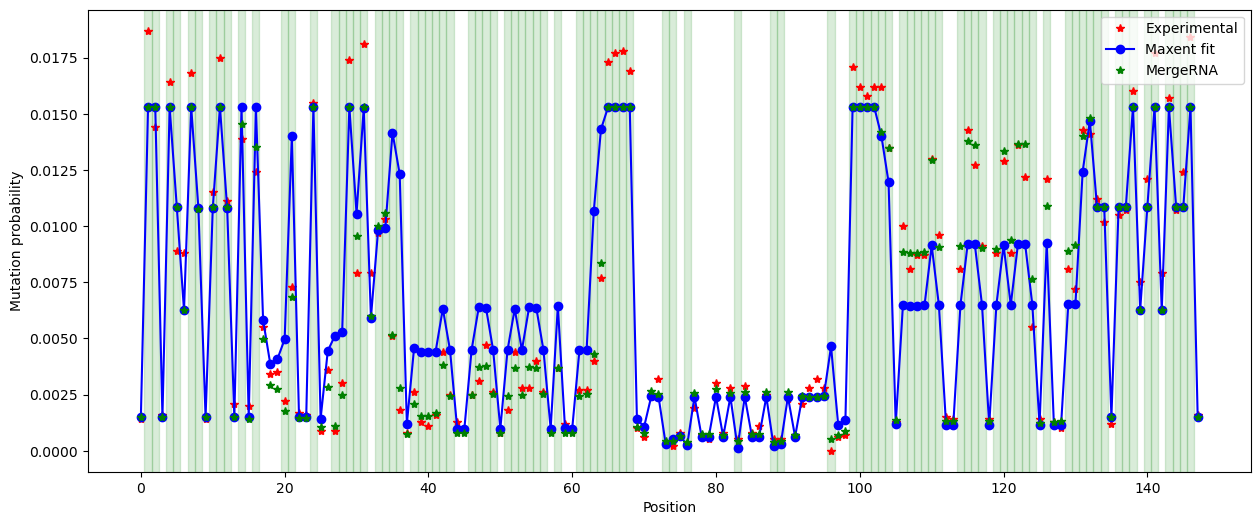

In [140]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(15, 6))

# plot your main series
ax.plot(mutation_counts/coverage_per_site, marker='*', linestyle=' ', color='red', label='Experimental')
ax.plot(a_from_merge+b_from_merge*res[1], marker='o', linestyle='-', color='blue', label='Maxent fit')
ax.plot(a_from_merge+b_from_merge*bpp_mergerna, marker='*', linestyle=' ', color='green', label='MergeRNA')

# shade regions based on the sequence
for i, nt in enumerate(sequence):
    if nt in ['A', 'C']:
        ax.axvspan(i - 0.5, i + 0.5, color='green', alpha=0.15, zorder=0)

ax.set_xlabel('Position')
ax.set_ylabel('Mutation probability')
ax.legend()
plt.show()

(0.0, 1.0)

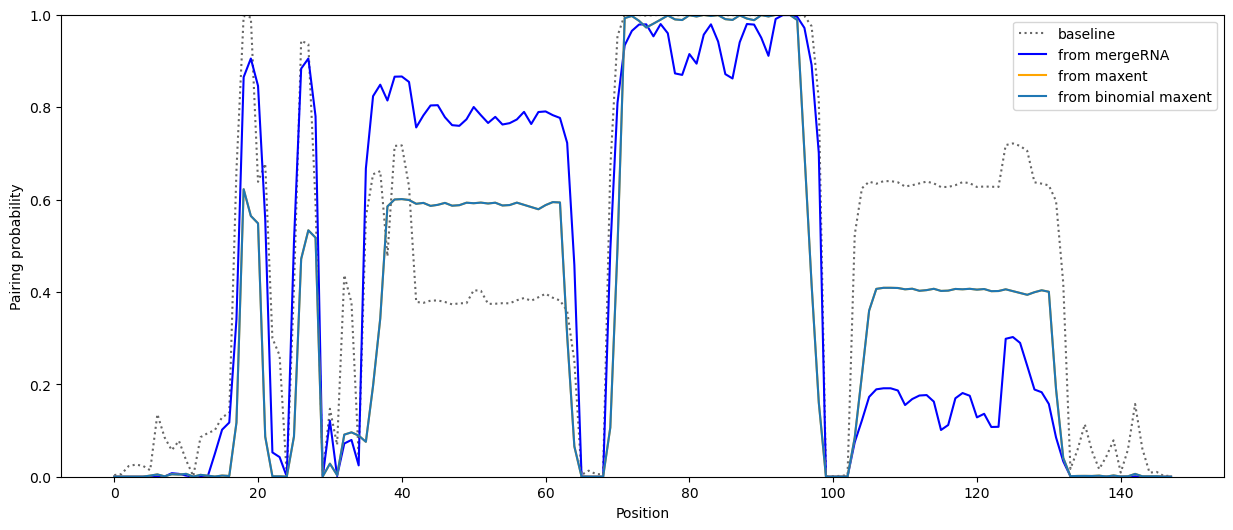

In [133]:
indices = np.arange(len(seq))
pp_baseline = bpp
pp_maxent = res[1]
#pp_binom_maxent = res_binom[1]
pp_binom_maxent = compute_ps_with_penalty_and_lambda(seq, res_binom[0].x, penalties, version=0, T=None, rescale=True)
pp_merge = bpp_mergerna

fig, ax = plt.subplots(1, 1, figsize=(15, 6))
ax.plot(indices, pp_baseline, label='baseline', linestyle=':', color='black', alpha=.6, linewidth=1.5)
ax.plot(indices, pp_merge, label=f'from mergeRNA', linestyle='-', color='blue')
ax.plot(indices, pp_maxent, label=f'from maxent', linestyle='-', color='orange')
ax.plot(indices, pp_binom_maxent, label=f'from binomial maxent', linestyle='-')
ax.set_xlabel('Position')
ax.set_ylabel('Pairing probability')
ax.legend()
ax.set_ylim(0,1)

(-0.05, 1.05)

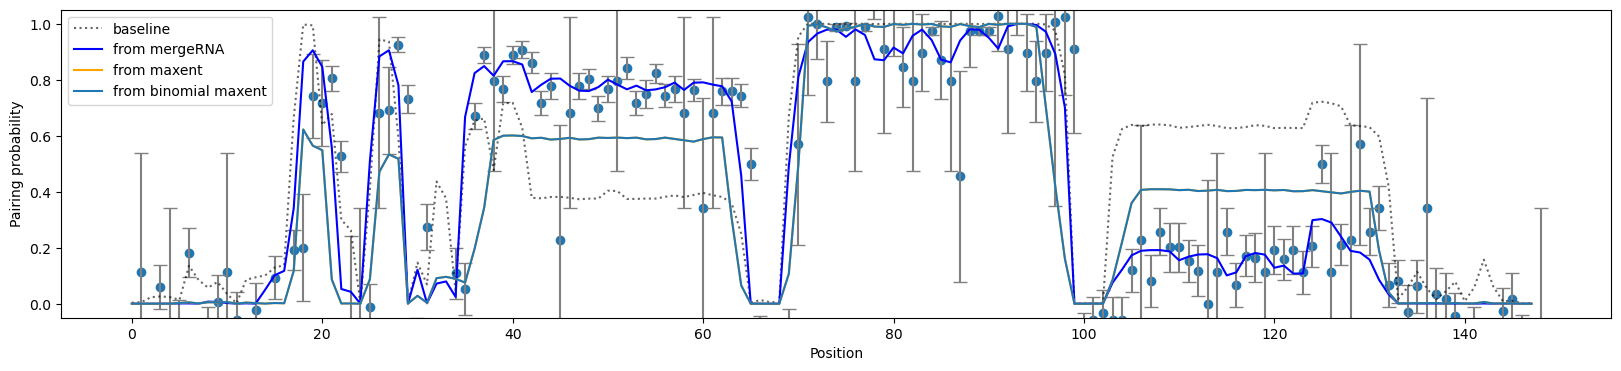

In [134]:
# positions along the sequence
positions = np.arange(1, len(sequence) + 1)

# b_from_fit is the array you already computed
y = target_contact_prob
y_errors = np.sqrt(squared_confidence_interval)

fig, ax = plt.subplots(1, 1, figsize=(20, 4))

ax.plot(positions, y, marker='o', linestyle='', linewidth=1.2, color='tab:blue')
ax.errorbar(positions, y, yerr=y_errors, ecolor='gray', fmt='none', capsize=5)

indices = np.arange(len(seq))
pp_baseline = bpp
pp_maxent = res[1]
#pp_binom_maxent = res_binom[1]
pp_binom_maxent = compute_ps_with_penalty_and_lambda(seq, res_binom[0].x, penalties, version=0, T=None, rescale=True)
pp_merge = bpp_mergerna

ax.plot(indices, pp_baseline, label='baseline', linestyle=':', color='black', alpha=.6, linewidth=1.5)
ax.plot(indices, pp_merge, label=f'from mergeRNA', linestyle='-', color='blue')
ax.plot(indices, pp_maxent, label=f'from maxent', linestyle='-', color='orange')
ax.plot(indices, pp_binom_maxent, label=f'from binomial maxent', linestyle='-')
ax.set_xlabel('Position')
ax.set_ylabel('Pairing probability')
ax.legend()
ax.set_ylim(-0.05,1.05)

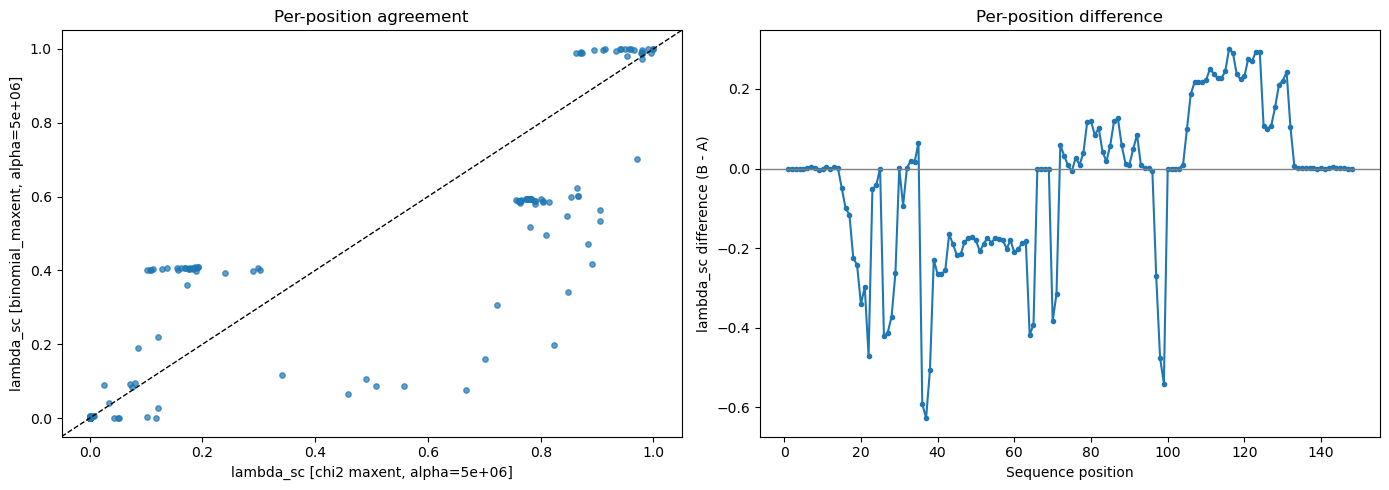

In [135]:
pairing_prob_a = pp_merge
pairing_prob_b = pp_binom_maxent

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(pairing_prob_a, pairing_prob_b, s=15, alpha=0.7)
lims = [-0.05, 1.05]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(f'lambda_sc [chi2 maxent, alpha={alpha:.3g}]')
ax.set_ylabel(f'lambda_sc [binomial_maxent, alpha={alpha:.3g}]')
ax.set_title('Per-position agreement')

ax = axes[1]
positions = np.arange(1, len(seq) + 1)
ax.plot(positions, pairing_prob_b - pairing_prob_a, '.-')
ax.axhline(0, color='gray', linewidth=1)
ax.set_xlabel('Sequence position')
ax.set_ylabel('lambda_sc difference (B - A)')
ax.set_title('Per-position difference')

plt.tight_layout()
plt.show()

(-0.05, 1.05)

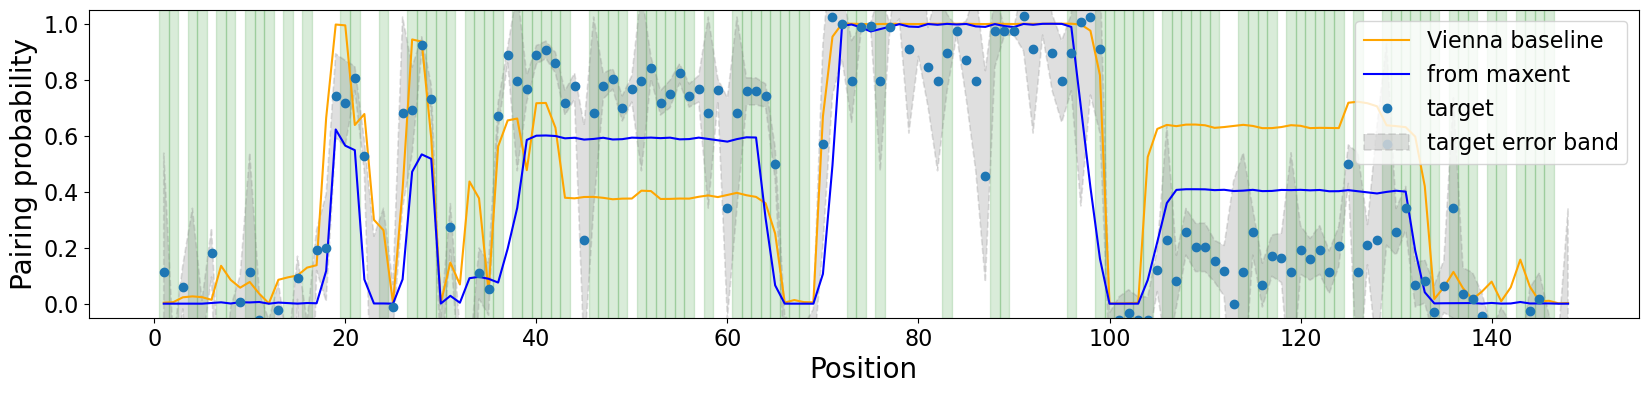

In [137]:
positions = np.arange(1, len(sequence) + 1)

y = target_contact_prob
y_errors = np.sqrt(squared_confidence_interval)
pp_merge = bpp_mergerna

fig, ax = plt.subplots(1, 1, figsize=(20, 4))

ax.plot(positions, pp_baseline, label='Vienna baseline', linestyle='-', color='orange')
#ax.plot(positions, pp_merge, label='from mergeRNA', linestyle='-', color='blue')
ax.plot(positions, pp_maxent, label=f'from maxent', linestyle='-', color='blue')
ax.plot(positions, y, marker='o', linestyle='', color='tab:blue', label='target')
ax.fill_between(positions, y - y_errors, y + y_errors, facecolor='gray', edgecolor='gray',
                 alpha=0.25, linestyle='--', linewidth=1.2, label='target error band')

for i, nt in enumerate(sequence):
    if nt in ['A', 'C']:
        ax.axvspan(i - 0.5, i + 0.5, color='green', alpha=0.15, zorder=0)

ax.set_xlabel('Position', fontsize=20)
ax.set_ylabel('Pairing probability', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16)
ax.set_ylim(-0.05, 1.05)

### Messy part that needs a fix

In [ ]:
def log_binomial(n, k):
    '''Compute the log of the binomial coefficient n choose k. Gammaln is an efficient way to compute the log of the factorial.'''
    return gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1)

In [ ]:
def my_mut_rate_profile(prob_base_pair, a, b):
    return a+b*prob_base_pair

In [ ]:
#I cut out the function the gradient part and the use of the position mask
def loss_binomial(*, mut_rate_model, mut_obs, coverage):
    """
    Compute the negative log-likelihood loss and (not) its gradient with respect to the parameters.
    Experimental data is retrieved from Experiment.df.
    Inputs:
        mut_rate_model: np.array, predicted mutation profile (values in (0,1))
        grad_of_mut_rate:    np.array, derivative matrix of the mutation profile with respect to parameters.
        compute_gradient: bool, whether to compute the gradient.
    Returns:
        loss: scalar, the negative log-likelihood loss.
        grad:  np.array containing the gradient with respect to parameters (or None if grad_of_mut_rate is None).
    """
    
    # Apply position mask to exclude masked positions from loss calculation
    ### not for now I do not mask positions
    # mut_obs_masked = mut_obs[self.position_mask]
    # coverage_masked = coverage[self.position_mask] 
    # mut_rate_model_masked = mut_rate_model[self.position_mask]
    mut_obs_masked = mut_obs
    coverage_masked = coverage
    mut_rate_model_masked = mut_rate_model
    # Numerical guard: prevent log/division singularities at exactly 0 or 1.
    # Keep epsilon tiny so low mutation-rate regime is not materially altered.
    eps_num = 1e-15
    mut_rate_model_masked = np.clip(mut_rate_model_masked, eps_num, 1.0 - eps_num)
    
    
    # Compute log of the binomial coefficient for each position
    log_binom = np.array([log_binomial(cov, mut) for cov, mut in zip(coverage_masked, mut_obs_masked)])
    # Compute the log-likelihood at each position
    log_prob = log_binom + (mut_obs_masked * np.log(mut_rate_model_masked) +
                            (coverage_masked - mut_obs_masked) * np.log(1 - mut_rate_model_masked))
    # Total negative log-likelihood loss (only from unmasked positions)
    loss = -np.sum(log_prob)
    
    return loss

In [ ]:
def loss_of_maxent(*, mut_rate_model, mut_obs, coverage, a_i, b_i):
    """
    Compute the negative loss of MAXent, so the quadratic expansion of the log-likelihood with respect to the parameters.

    Inputs:
        mut_rate_model: np.array, predicted mutation profile (values in (0,1))
        grad_of_mut_rate:    np.array, derivative matrix of the mutation profile with respect to parameters.
        compute_gradient: bool, whether to compute the gradient.
    Returns:
        loss: scalar, the negative log-likelihood loss.
    """
    
    # Apply position mask to exclude masked positions from loss calculation
    ### not for now I do not mask positions
    # mut_obs_masked = mut_obs[self.position_mask]
    # coverage_masked = coverage[self.position_mask] 
    # mut_rate_model_masked = mut_rate_model[self.position_mask]
    mut_obs_masked = mut_obs
    coverage_masked = coverage
    mut_rate_model_masked = mut_rate_model
    # Numerical guard: prevent log/division singularities at exactly 0 or 1.
    # Keep epsilon tiny so low mutation-rate regime is not materially altered.
    eps_num = 1e-15
    mut_rate_model_masked = np.clip(mut_rate_model_masked, eps_num, 1.0 - eps_num)
    
    
    # Compute log of the binomial coefficient for each position
    log_binom = np.array([log_binomial(cov, mut) for cov, mut in zip(coverage_masked, mut_obs_masked)])
    # Compute the log-likelihood at each position at the max, so mut prob is given by mut count
    mut_observed = mut_obs_masked / coverage_masked
    log_prob_at_max = log_binom + (mut_obs_masked * np.log(mut_observed) +
                            (coverage_masked - mut_obs_masked) * np.log(1 - mut_observed))

    S_exp_i, sigma_squared_i = compute_expansion_parameters(mut_obs_masked, coverage_masked, a_i, b_i)
    S_from_model = (mut_rate_model_masked-a_i)/b_i
    ki_squared = (S_from_model - S_exp_i)**2 / sigma_squared_i
    
    # Total negative log-likelihood loss (only from unmasked positions)
    loss = -np.sum(log_prob_at_max) + 0.5 * np.sum(ki_squared) 
    
    return loss

In [ ]:
def kl_divergence(lambdas, alpha, seq, penalties):

    kb=1.98717/1000 # grepped from vienna source code
    kBT = ((RNA.cvar.temperature + 273.15) * kb)

    p_sb = compute_ps_with_penalty_and_lambda(seq, lambdas, penalties, version=0, T=None, rescale=True)
    
    F_lam = compute_free_energy_with_penalty_and_lambda(seq, lambdas, penalties, version=0, T=None, rescale=True)
    F0 = compute_free_energy_with_penalty_and_lambda(seq, np.zeros(len(lambdas)), penalties, version=0, T=None, rescale=True)

    kl = (-np.dot(lambdas, p_sb) + (F_lam - F0)) / kBT
    return kl

In [ ]:
bpp_target_cut = bpp_target.copy()
for i in range(len(seq)):
    if bpp_target[i]<0:
        bpp_target_cut[i]=0
    elif bpp_target[i]>1:
        bpp_target_cut[i]=1

likelihood_max = loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_target_cut,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)
likelihood_max

In [ ]:
# true loss evaluated from binomial maxent pairing probs
bpp_binomial = compute_ps_with_penalty_and_lambda(seq, res_binom[0].x, penalties, version=0, T=None, rescale=True)
likelihood_bin_maxent_res = loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_binomial,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)
likelihood_bin_maxent_res

In [ ]:
likelihood_bin_maxent_res+alpha*kl_divergence(lambdas=res_binom[0].x,alpha=alpha, seq=seq, penalties=penalties)

In [ ]:
# true loss evaluated from binomial maxent pairing probs
# corrected by the gradient
loss_binomial(mut_rate_model=my_mut_rate_profile(res_binom[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

In [ ]:
# true loss evaluated from maxent pairing probs
bpp_chisquared = compute_ps_with_penalty_and_lambda(seq, res[0].x, penalties, version=0, T=None, rescale=True)
likelihood_chi_maxent_res=loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_chisquared,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)
likelihood_chi_maxent_res

In [ ]:
likelihood_chi_maxent_res+alpha*kl_divergence(lambdas=res[0].x,alpha=alpha, seq=seq, penalties=penalties)

In [ ]:
# true loss evaluated from maxent pairing probs
# corrected by the gradient
loss_binomial(mut_rate_model=my_mut_rate_profile(res[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

In [ ]:
# true loss evaluated from merge rna pairing probs
loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_mergerna,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)

In [ ]:
# maxent loss evaluated from maxent pairing probs
loss_of_maxent(mut_rate_model=my_mut_rate_profile(res[1],a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site, a_i=a_from_merge, b_i=b_from_merge)

In [ ]:
# maxent loss evaluated from merge rna pairing probs
loss_of_maxent(mut_rate_model=my_mut_rate_profile(bpp_mergerna,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site, a_i=a_from_merge, b_i=b_from_merge)

In [ ]:
res_binom_2=maxent_binomial(seq,initial_guess=lambdas_merge_rna, mutation_counts=mutation_counts, trials_counts=coverage_per_site, a_phys=a_from_merge, b_phys=b_from_merge, penalty= penalties, boundaries=boundaries,alpha=alpha,deriv_correction=False, tol=tol,T=phys_const_from_fit_metadata['temp_C'])
res_binom_2

In [ ]:
# true loss evaluated from binomial maxent pairing probs
bpp_binomial = compute_ps_with_penalty_and_lambda(seq, res_binom_2[0].x, penalties, version=0, T=None, rescale=True)
likelihood_bin_maxent_res = loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_binomial,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)
likelihood_bin_maxent_res

In [ ]:
likelihood_bin_maxent_res+alpha*kl_divergence(lambdas=res_binom_2[0].x,alpha=alpha, seq=seq, penalties=penalties)

In [ ]:
res_2=maxent(seq, bpp_target,initial_guess=lambdas_merge_rna, sigma_squared=squared_confidence_interval, penalty= penalties, boundaries=boundaries,alpha=alpha,deriv_correct=False, tol=tol,T=phys_const_from_fit_metadata['temp_C'])
res_2

In [ ]:
# true loss evaluated from binomial maxent pairing probs
bpp_chisquared = compute_ps_with_penalty_and_lambda(seq, res_2[0].x, penalties, version=0, T=None, rescale=True)
likelihood_chi_maxent_res=loss_binomial(mut_rate_model=my_mut_rate_profile(bpp_chisquared,a_from_merge, b_from_merge), mut_obs=mutation_counts, coverage=coverage_per_site)
likelihood_chi_maxent_res

In [ ]:
likelihood_chi_maxent_res+alpha*kl_divergence(lambdas=res_2[0].x,alpha=alpha, seq=seq, penalties=penalties)